In [2]:
import shutil
import torch
from torchvision import datasets
from torchmetrics.classification import JaccardIndex
from torch.utils.data import Dataset ,DataLoader
from torchvision.transforms import ToTensor
import torch.nn as nn
import pandas as pd
import numpy as np
from torch.optim import lr_scheduler

In [3]:
%pip install segmentation_models_pytorch torchsummary

Note: you may need to restart the kernel to use updated packages.


In [4]:
import json 
with open('/kaggle/input/brain-tumor-image-dataset-semantic-segmentation/valid/_annotations.coco.json','r') as file:
    data = json.load(file)

for img in data['images'][:100]:
    print(img['file_name'])

1997_jpg.rf.57e306420710246d04c0d5c26e6496c6.jpg
2422_jpg.rf.59a35b6d8d2eed150af8535cf09bbde5.jpg
1630_jpg.rf.5afc6e25d7987503a11bcb0791b60b53.jpg
1330_jpg.rf.5b23bf18a29b0f50e376b19a5a84f823.jpg
2768_jpg.rf.5b87c0023909e0789a33185a3aab92e9.jpg
2647_jpg.rf.5ba404374f2d670f04a2d1367c77c039.jpg
1511_jpg.rf.5c02bb67a267960293c9e8393c2d9380.jpg
1018_jpg.rf.5c6fcb4480745ff7c60c7305781913ab.jpg
1694_jpg.rf.5c8d647ce366cbd41426af5217863bd4.jpg
2824_jpg.rf.5ca7452639b345dfd0206a58531b6910.jpg
1308_jpg.rf.5dfa6eaf7fbd7f25726601b80ad3e924.jpg
1075_jpg.rf.5f1ff03eca9e83f286fc386d1003e0aa.jpg
2676_jpg.rf.5c8d96f744f98305f81e90988ce874d0.jpg
1237_jpg.rf.5dc3a6884c4c1ed0bd2234f9f2952db9.jpg
2165_jpg.rf.5f4ee29470d91f44c5e429080a04dbe5.jpg
1615_jpg.rf.5f91ee7e6b7b04789a8712ff86bc7e94.jpg
2405_jpg.rf.600b59b0151dcef2996acf8d0f9b914a.jpg
2130_jpg.rf.60e026f1e4c3e83234c3cc8d157997f1.jpg
1514_jpg.rf.5fa3aca95a87888ffe6a56254827a31d.jpg
2774_jpg.rf.5fa9268ff313662770182dacdfc832d8.jpg
2857_jpg.rf.63190417

In [5]:
import json
import numpy as np
import skimage.draw
import tifffile
import os
import matplotlib.pyplot as plt

def generate_mask(image_info, annotations, save_directory, max_masks=3):
    # Initialize an empty numpy array for the mask
    mask = np.zeros((image_info['height'], image_info['width']), dtype=np.uint8)
    mask_count = 0  # Tracks the number of masks generated
    
    for annotation in annotations:
        if annotation['image_id'] == image_info['id']:
            for index, segment in enumerate(annotation['segmentation']):
                row, col = skimage.draw.polygon(segment[1::2], segment[0::2], mask.shape)
                # Create a temporary mask for the current segmentation
                segment_mask = np.zeros_like(mask, dtype=np.uint8)
                segment_mask[row, col] = 255  # Mark the polygon pixels with 255
                file_path = os.path.join(save_directory, f"{image_info['file_name'].replace('.jpg', '')}_segment_{index}.tif")
                tifffile.imwrite(file_path, segment_mask)
                
                mask_count += 1
                if mask_count >= max_masks:
                    return  # Stop after generating the specified number of masks


In [6]:
def process_images(json_file, mask_save_dir, image_save_dir, original_images_dir):
    # Load the COCO-format JSON annotations
    with open(json_file, 'r') as file:
        dataset = json.load(file)

    images = dataset['images']
    annotations = dataset['annotations']

    # Create the output directories if they do not already exist
    os.makedirs(mask_save_dir, exist_ok=True)
    os.makedirs(image_save_dir, exist_ok=True)

    for image in images:
        # Generate the masks for the image
        generate_mask(image, annotations, mask_save_dir)
        
        # Copy the original image to the target directory
        source_image_path = os.path.join(original_images_dir, image['file_name'])
        destination_image_path = os.path.join(image_save_dir, os.path.basename(source_image_path))
        shutil.copy2(source_image_path, destination_image_path)


In [7]:
# Paths and directories for test dataset
test_image_dir = '/kaggle/input/brain-tumor-image-dataset-semantic-segmentation/test'  # Path to original images
test_json_file = '/kaggle/input/brain-tumor-image-dataset-semantic-segmentation/test/_annotations.coco.json'
test_mask_save_dir = 'test2/masks'  # Directory for saving masks
test_image_save_dir = 'test2/images'  # Directory for saving images
process_images(test_json_file, test_mask_save_dir, test_image_save_dir, test_image_dir)

# Paths and directories for train dataset
train_image_dir = '/kaggle/input/brain-tumor-image-dataset-semantic-segmentation/train'  # Path to original images
train_json_file = '/kaggle/input/brain-tumor-image-dataset-semantic-segmentation/train/_annotations.coco.json'
train_mask_save_dir = 'train2/masks'  # Directory for saving masks
train_image_save_dir = 'train2/images'  # Directory for saving images
process_images(train_json_file, train_mask_save_dir, train_image_save_dir, train_image_dir)

# Paths and directories for validation dataset
valid_image_dir = '/kaggle/input/brain-tumor-image-dataset-semantic-segmentation/valid'  # Path to original images
valid_json_file = '/kaggle/input/brain-tumor-image-dataset-semantic-segmentation/valid/_annotations.coco.json'
valid_mask_save_dir = 'valid2/masks'  # Directory for saving masks
valid_image_save_dir = 'valid2/images'  # Directory for saving images
process_images(valid_json_file, valid_mask_save_dir, valid_image_save_dir, valid_image_dir)


In [8]:
def sync_and_delete_unmatched_items(folder1, folder2):
    # List the items in both folders
    folder1_contents = os.listdir(folder1)
    folder2_contents = os.listdir(folder2)

    # Check for unmatched items in folder1
    for item in folder1_contents:
        if not any(item[:4] == f[:4] for f in folder2_contents):
            print(f"No match found for {item} in {folder2}. Deleting...")
            os.remove(os.path.join(folder1, item))
            print(f"Deleted {item} from {folder1}")

    # Check for unmatched items in folder2
    for item in folder2_contents:
        if not any(item[:4] == f[:4] for f in folder1_contents):
            print(f"No match found for {item} in {folder1}. Deleting...")
            os.remove(os.path.join(folder2, item))
            print(f"Deleted {item} from {folder2}")

# Example usage:
folder1 = "/kaggle/working/valid2/images"
folder2 = "/kaggle/working/valid2/masks"
sync_and_delete_unmatched_items(folder1, folder2)


In [9]:
BATCH_SIZE = 16
NUM_EPOCHS = 10
LEARNING_RATE =1e-3

In [10]:
import os
from torch.utils.data import DataLoader, Dataset
from torchvision import transforms
from PIL import Image

class GeneralDataset(Dataset):
    def __init__(self, root_directory, transform=None):
        self.root_directory = root_directory
        self.image_dir = os.path.join(root_directory, "images")
        self.mask_dir = os.path.join(root_directory, "masks")
        self.image_files = sorted(os.listdir(self.image_dir))
        self.mask_files = sorted(os.listdir(self.mask_dir))
        self.transform = transform

    def __len__(self):
        return len(self.mask_files)

    def __getitem__(self, index):
        # Load image
        image_file = self.image_files[index]
        image_path = os.path.join(self.image_dir, image_file)
        image = Image.open(image_path).convert("RGB")
        grayscale_image = image.convert("L")  # Convert to grayscale

        # Load corresponding mask
        mask_file = self.mask_files[index]
        mask_path = os.path.join(self.mask_dir, mask_file)
        mask = Image.open(mask_path).convert("L")

        # Apply transformations if available
        if self.transform:
            grayscale_image = self.transform(grayscale_image)
            mask = self.transform(mask)

        return grayscale_image, mask

# Set paths for datasets
train_directory = "/kaggle/working/train2"
valid_directory = "/kaggle/working/valid2"
test_directory = "/kaggle/working/test2"

# Define transformations for image and mask
transformation = transforms.Compose([
    transforms.Resize(224),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485], std=[0.229]),  # For grayscale images
    transforms.Lambda(lambda x: x.clamp(0, 1))  # Ensure values are clamped between 0 and 1
])

# Initialize datasets
train_data = GeneralDataset(train_directory, transform=transformation)
valid_data = GeneralDataset(valid_directory, transform=transformation)
test_data = GeneralDataset(test_directory, transform=transformation)

# Data loaders with batching and shuffling
train_loader = DataLoader(train_data, batch_size=BATCH_SIZE, shuffle=True)
valid_loader = DataLoader(valid_data, batch_size=BATCH_SIZE, shuffle=False)
test_loader = DataLoader(test_data, batch_size=BATCH_SIZE, shuffle=False)


In [11]:
print(len(train_loader))
print(len(valid_loader))
print(len(test_loader))


94
27
14


In [12]:
if len(train_loader) > 0:
    images, masks = next(iter(train_loader))
    print(f"Image shape: {images.shape}, Mask shape: {masks.shape}")
    print(f"Image type: {type(images)}, Mask type: {type(masks)}")
else:
    print("The training loader is empty.")


Image shape: torch.Size([16, 1, 224, 224]), Mask shape: torch.Size([16, 1, 224, 224])
Image type: <class 'torch.Tensor'>, Mask type: <class 'torch.Tensor'>


# Unet2

Epoch 10/10, Train Loss: 0.3955, Train Jaccard: 0.5663, Train Accuracy: 0.9785
Validation Loss: 0.4985, Validation Jaccard: 0.4788, Validation Accuracy: 0.9702


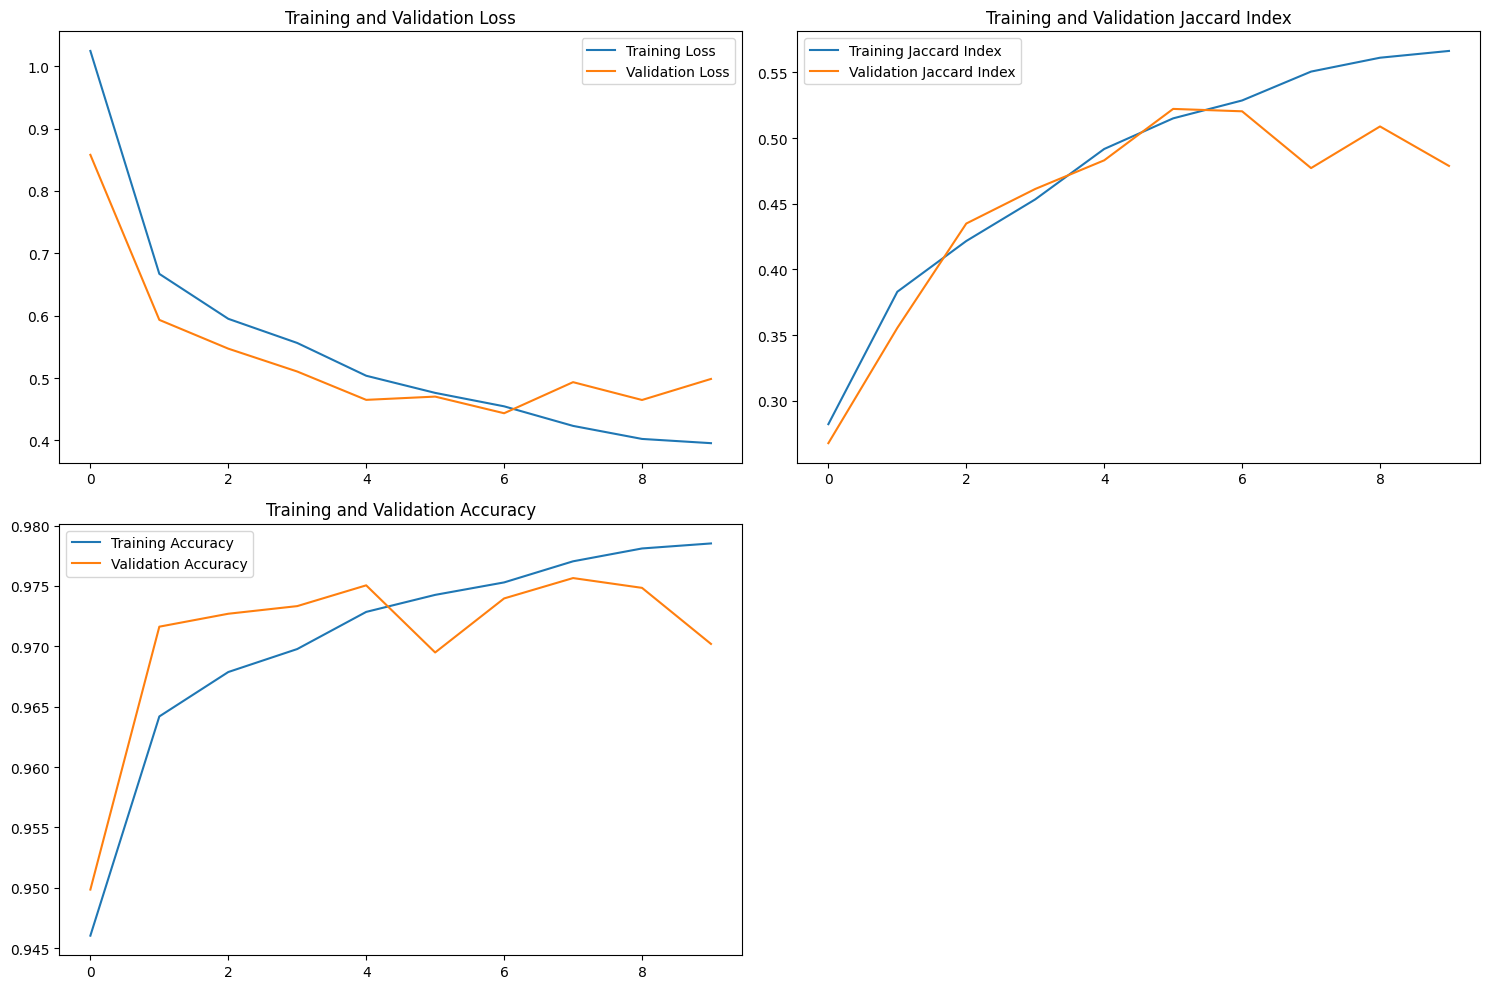

In [13]:
import segmentation_models_pytorch as smp
import torch
import torch.nn as nn
import torch.optim as optim
import torchsummary
from torchvision import transforms
from tqdm import tqdm
from IPython.display import clear_output
import matplotlib.pyplot as plt
import albumentations as A
from albumentations.pytorch import ToTensorV2

# Define Dice Loss Function
class DiceLoss(nn.Module):
    def __init__(self):
        super(DiceLoss, self).__init__()

    def forward(self, y_pred, y_true):
        smooth = 1e-6
        y_pred = torch.sigmoid(y_pred).view(-1)
        y_true = y_true.view(-1)
        intersection = (y_pred * y_true).sum()
        return 1 - (2. * intersection + smooth) / (y_pred.sum() + y_true.sum() + smooth)

# Define Combined Loss Function
class CombinedLoss(nn.Module):
    def __init__(self):
        super(CombinedLoss, self).__init__()
        self.dice_loss = DiceLoss()
        self.bce_loss = nn.BCEWithLogitsLoss()

    def forward(self, y_pred, y_true):
        dice_loss = self.dice_loss(y_pred, y_true)
        bce_loss = self.bce_loss(y_pred, y_true)
        return dice_loss + bce_loss

# Jaccard Index Function
def jaccard_index(predictions, targets, smooth=1e-10):
    predictions = (predictions > 0.5).float()
    intersection = (predictions * targets).sum(dim=(2, 3))
    union = predictions.sum(dim=(2, 3)) + targets.sum(dim=(2, 3)) - intersection
    return (intersection + smooth) / (union + smooth)

# Accuracy Calculation
def calculate_accuracy(predictions, targets):
    predictions = (predictions > 0.5).float()
    correct = (predictions == targets).float().sum()  # Count correct predictions
    accuracy = correct / (targets.numel())  # Divide by total number of pixels
    return accuracy.item()

# Training Function
def train_model(model, optimizer, loss_function, data_loader, device):
    total_loss = 0.0
    total_jaccard = 0.0
    total_accuracy = 0.0
    model.train()

    for inputs, targets in tqdm(data_loader):
        inputs = inputs.to(device, dtype=torch.float32)
        targets = targets.to(device, dtype=torch.float32)

        optimizer.zero_grad()
        predictions = model(inputs)
        loss = loss_function(predictions, targets)
        loss.backward()
        optimizer.step()

        total_loss += loss.item()
        batch_jaccard = jaccard_index(predictions, targets).mean().item()
        total_jaccard += batch_jaccard
        batch_accuracy = calculate_accuracy(predictions, targets)
        total_accuracy += batch_accuracy

    avg_loss = total_loss / len(data_loader)
    avg_jaccard = total_jaccard / len(data_loader)
    avg_accuracy = total_accuracy / len(data_loader)
    return avg_loss, avg_jaccard, avg_accuracy

# Validation Function
def validate_model(model, data_loader, loss_function, device):
    total_loss = 0.0
    total_jaccard = 0.0
    total_accuracy = 0.0
    model.eval()

    with torch.no_grad():
        for inputs, targets in data_loader:
            inputs = inputs.to(device, dtype=torch.float32)
            targets = targets.to(device, dtype=torch.float32)

            predictions = model(inputs)
            loss = loss_function(predictions, targets)
            total_loss += loss.item()

            batch_jaccard = jaccard_index(predictions, targets).mean().item()
            total_jaccard += batch_jaccard
            batch_accuracy = calculate_accuracy(predictions, targets)
            total_accuracy += batch_accuracy

    avg_loss = total_loss / len(data_loader)
    avg_jaccard = total_jaccard / len(data_loader)
    avg_accuracy = total_accuracy / len(data_loader)
    return avg_loss, avg_jaccard, avg_accuracy

# Model configuration
ENCODER = 'resnet34'  # Use ResNet34 as the encoder
ENCODER_WEIGHTS = 'imagenet'
DEVICE = 'cuda' if torch.cuda.is_available() else 'cpu'

# Define the Unet model
unet2 = smp.Unet(
    encoder_name=ENCODER,
    encoder_weights=ENCODER_WEIGHTS,
    in_channels=1,  # Input channels for grayscale images
    classes=1,      # Output classes
    activation=None
)

# Move the model to the specified device
unet2.to(DEVICE)

# Print the summary of unet2 model
print(torchsummary.summary(unet2, (1, 224, 224)))

# Define Data Transformations with Albumentations
def get_transforms():
    return A.Compose([
        A.Resize(224, 224),
        A.HorizontalFlip(),
        A.VerticalFlip(),
        A.RandomRotate90(),
        A.RandomBrightnessContrast(),
        A.Normalize(mean=(0.485,), std=(0.229,)),
        ToTensorV2()
    ])

# Define Optimizer and Scheduler
LEARNING_RATE = 0.001
optimizer = optim.Adam(unet2.parameters(), lr=LEARNING_RATE)
scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, 'min', patience=2, factor=0.5)
loss_fn = CombinedLoss()

# Variables for training
NUM_EPOCHS = 10
best_validation_loss = float('inf')
num_no_improve = 0
train_losses = []
val_losses = []
train_jaccards = []
val_jaccards = []
train_accuracies = []
val_accuracies = []

# Training Loop
for epoch in range(NUM_EPOCHS):
    train_loss, train_jaccard, train_accuracy = train_model(unet2, optimizer, loss_fn, train_loader, DEVICE)
    val_loss, val_jaccard, val_accuracy = validate_model(unet2, valid_loader, loss_fn, DEVICE)

    train_losses.append(train_loss)
    val_losses.append(val_loss)
    train_jaccards.append(train_jaccard)
    val_jaccards.append(val_jaccard)
    train_accuracies.append(train_accuracy)
    val_accuracies.append(val_accuracy)

    clear_output(wait=True)
    print(f'Epoch {epoch + 1}/{NUM_EPOCHS}, Train Loss: {train_loss:.4f}, Train Jaccard: {train_jaccard:.4f}, Train Accuracy: {train_accuracy:.4f}')
    print(f'Validation Loss: {val_loss:.4f}, Validation Jaccard: {val_jaccard:.4f}, Validation Accuracy: {val_accuracy:.4f}')

    # Save the best model
    if val_loss < best_validation_loss:
        best_validation_loss = val_loss
        torch.save(unet2.state_dict(), 'best_model.pth')  # Save the best model weights
        print("Saving the best model...")

    # Learning rate scheduler
    scheduler.step(val_loss)

    # Early stopping logic
    if num_no_improve >= 5:
        print("Early stopping triggered.")
        break

# Plotting the training and validation losses, Jaccard indices, and accuracies
plt.figure(figsize=(15, 10))

# Loss Plot
plt.subplot(2, 2, 1)
plt.plot(train_losses, label='Training Loss')
plt.plot(val_losses, label='Validation Loss')
plt.title('Training and Validation Loss')
plt.legend()

# Jaccard Index Plot
plt.subplot(2, 2, 2)
plt.plot(train_jaccards, label='Training Jaccard Index')
plt.plot(val_jaccards, label='Validation Jaccard Index')
plt.title('Training and Validation Jaccard Index')
plt.legend()

# Accuracy Plot
plt.subplot(2, 2, 3)
plt.plot(train_accuracies, label='Training Accuracy')
plt.plot(val_accuracies, label='Validation Accuracy')
plt.title('Training and Validation Accuracy')
plt.legend()

plt.tight_layout()
plt.show()


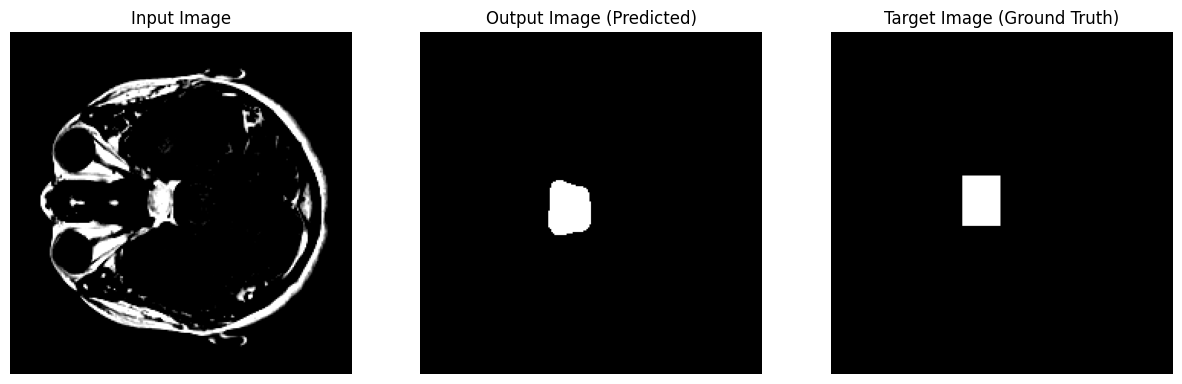

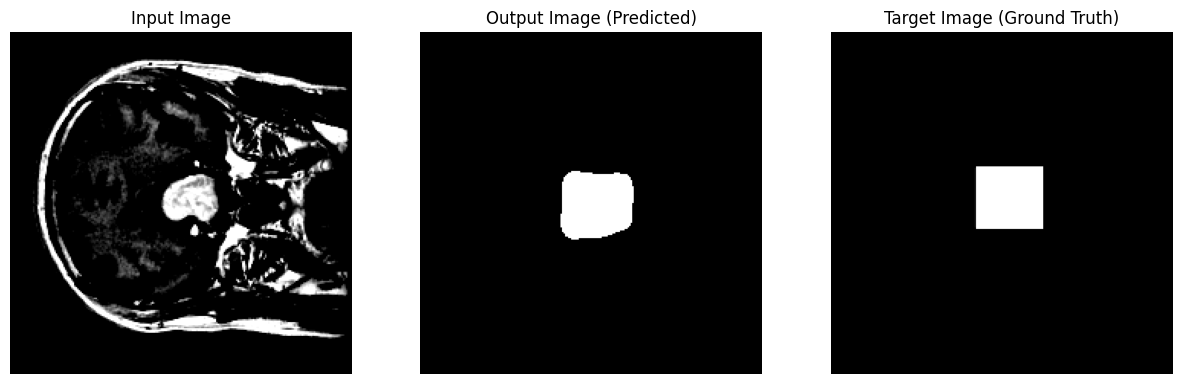

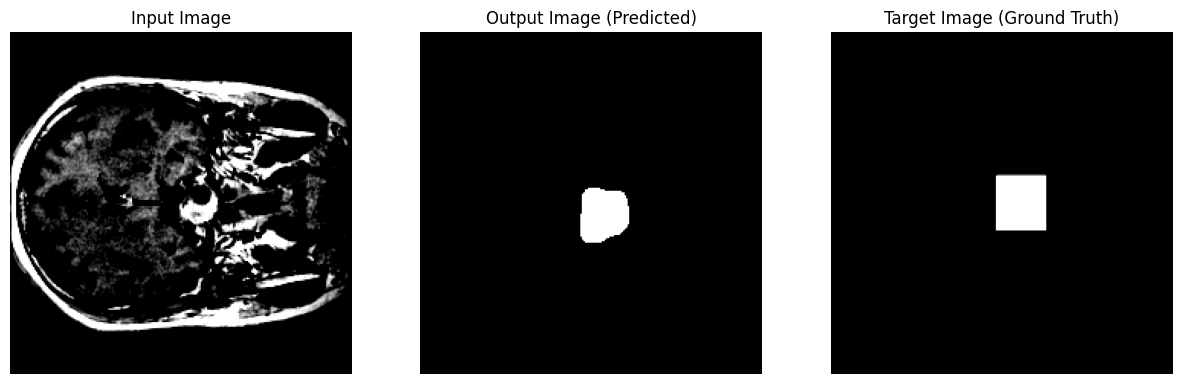

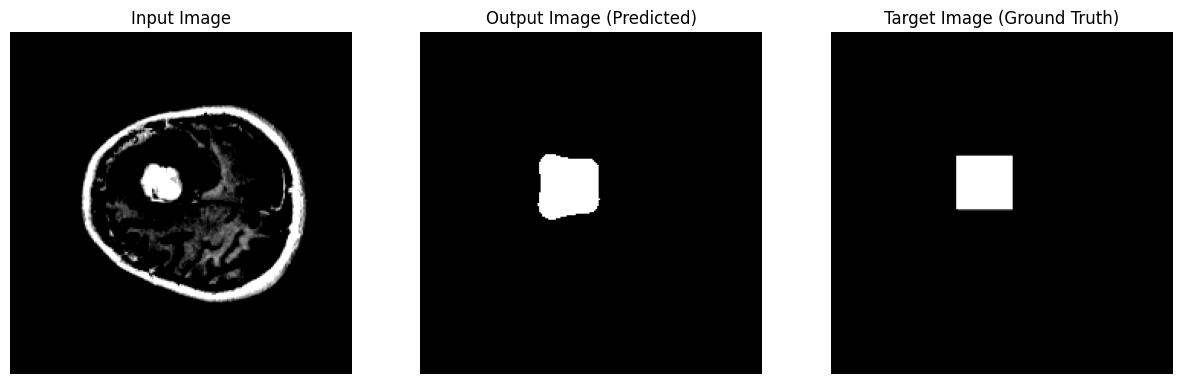

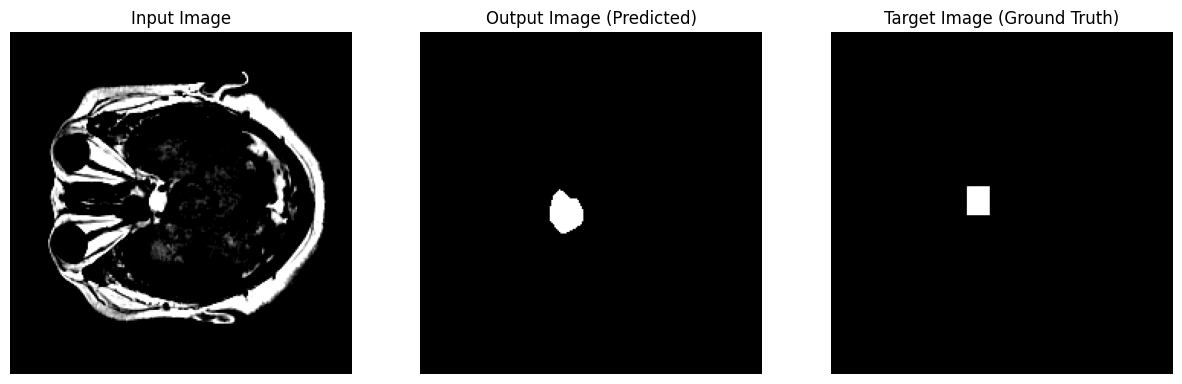

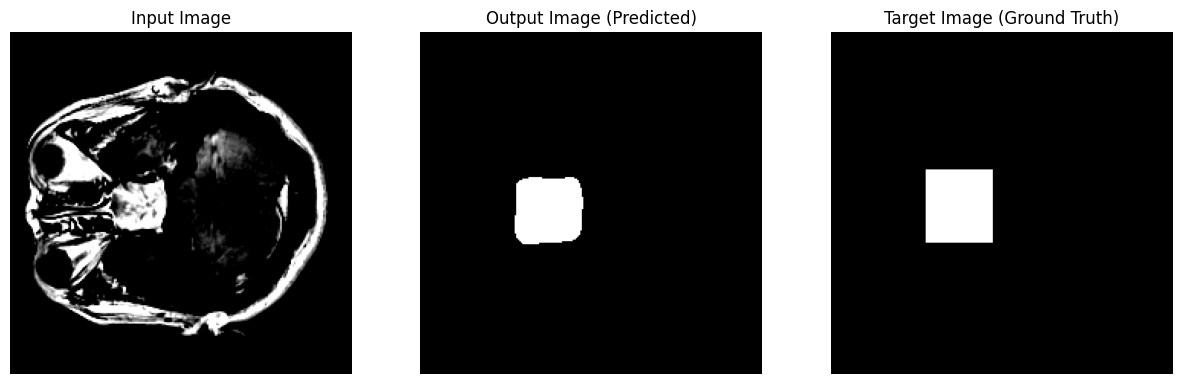

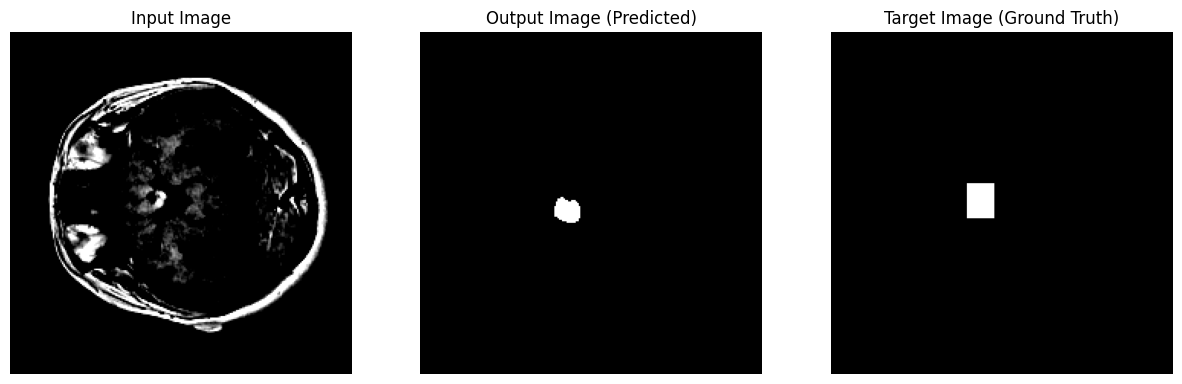

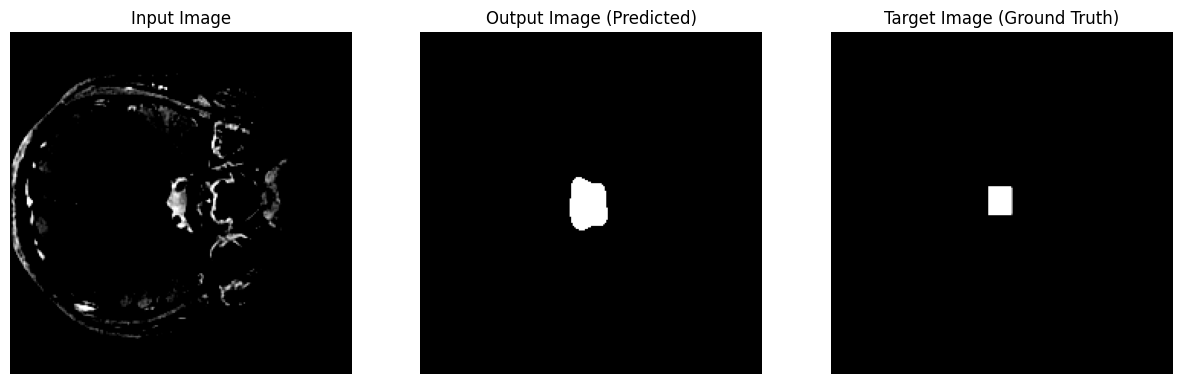

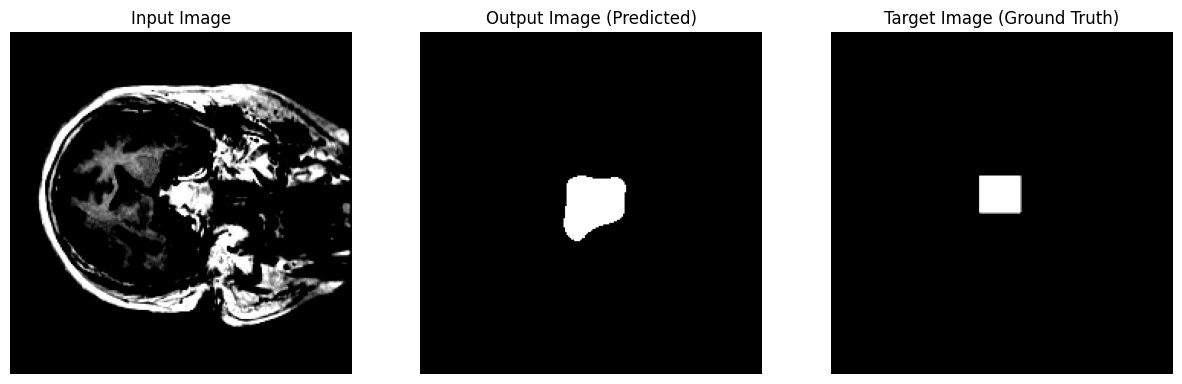

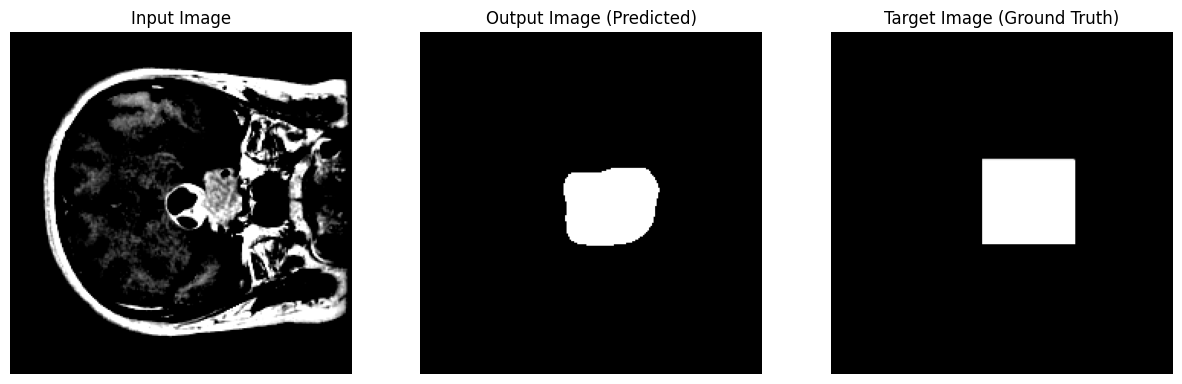

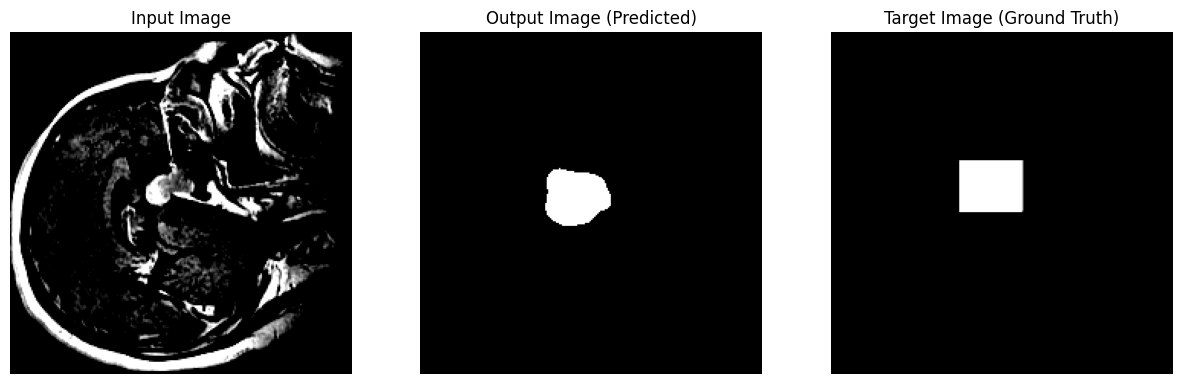

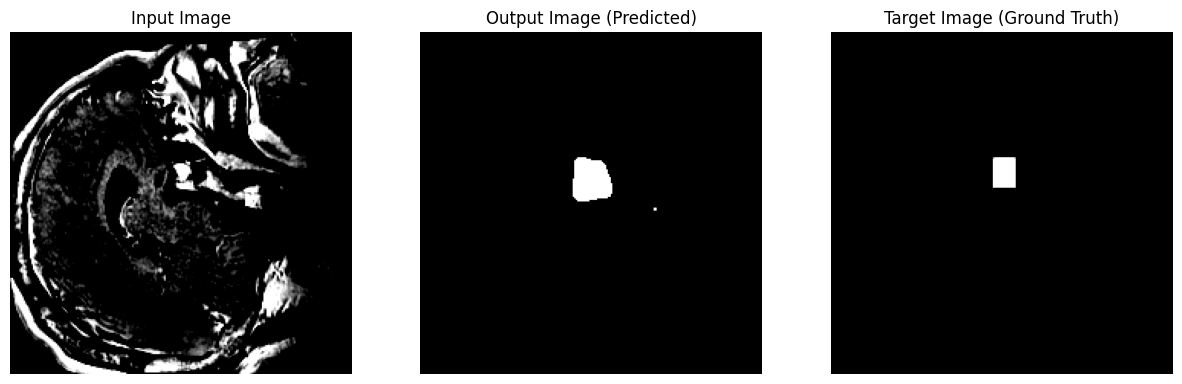

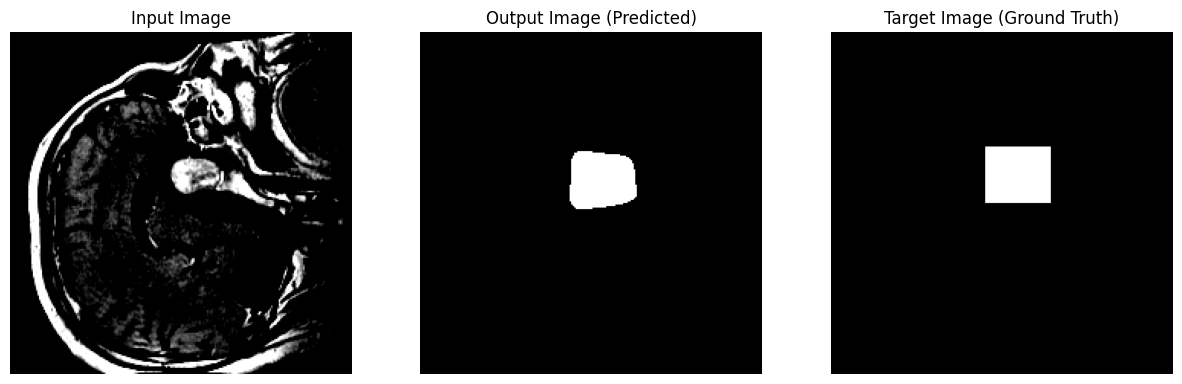

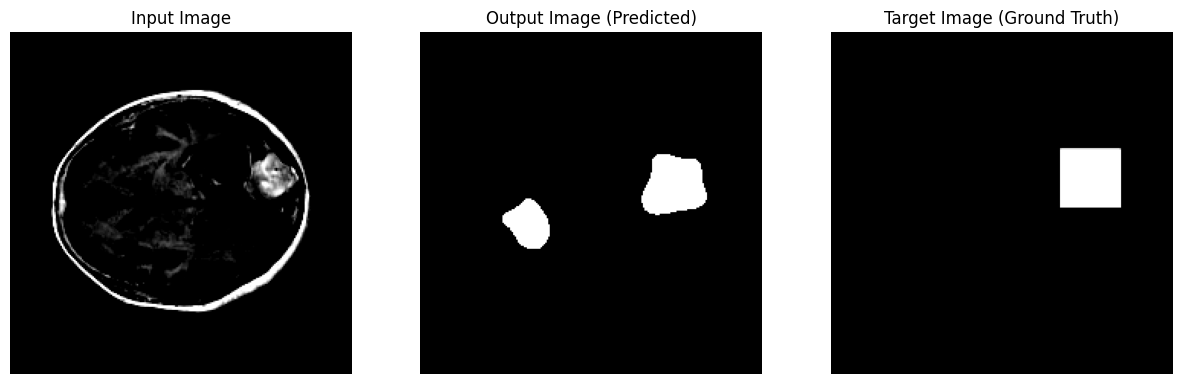

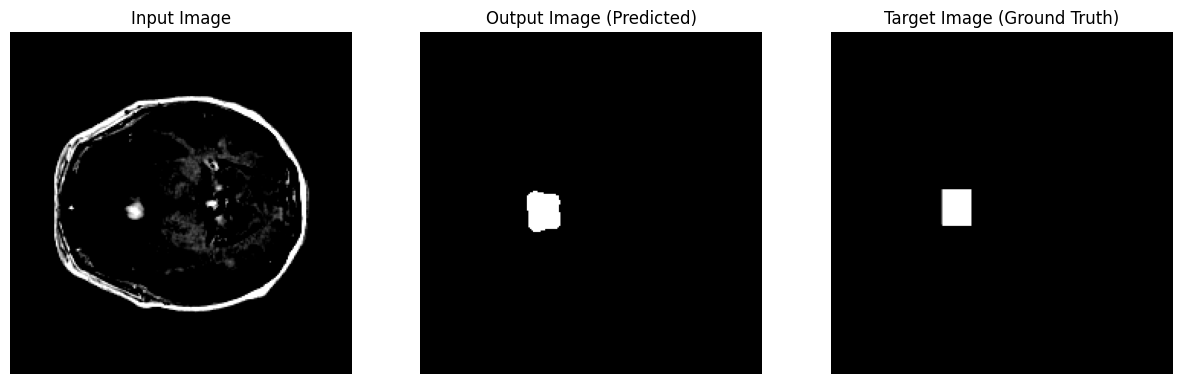

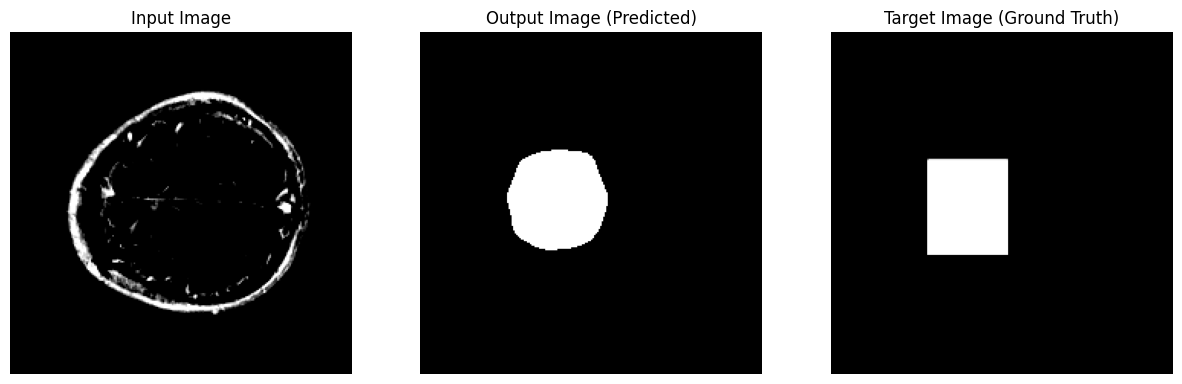

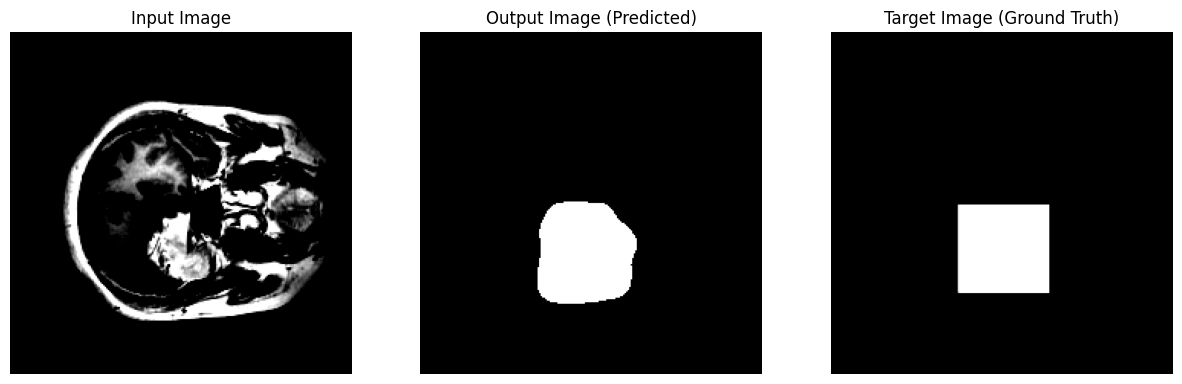

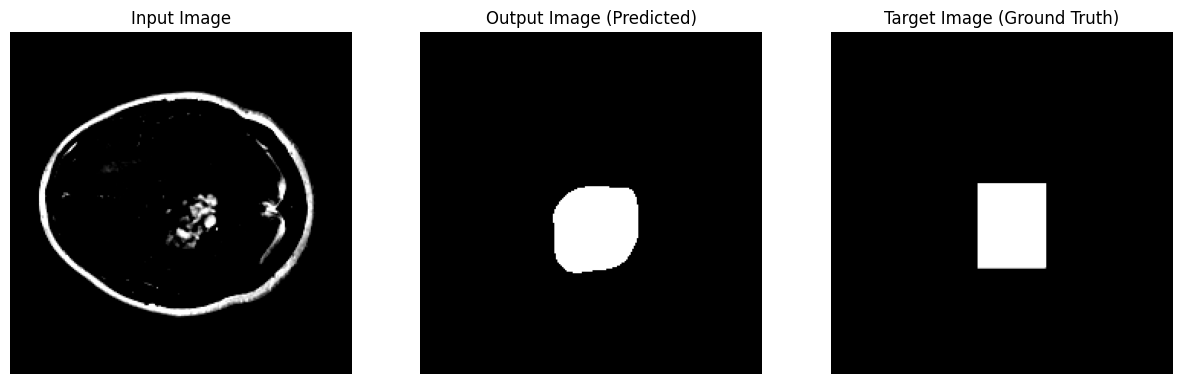

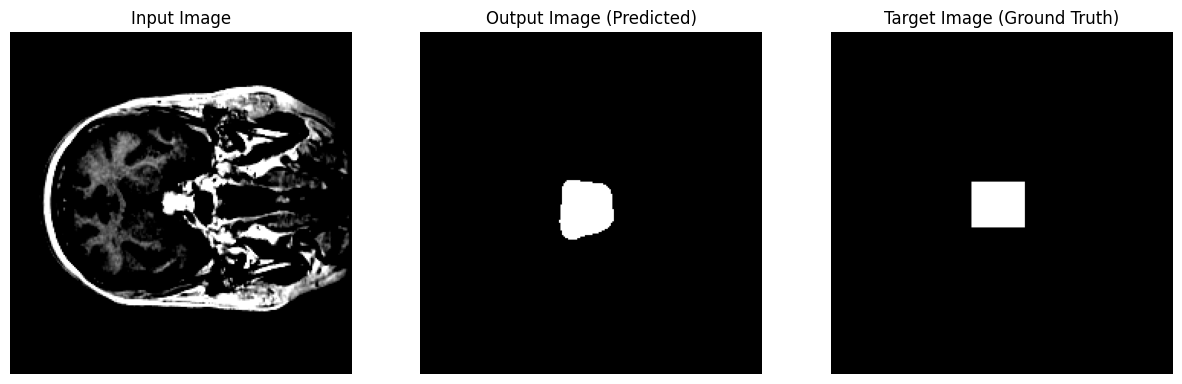

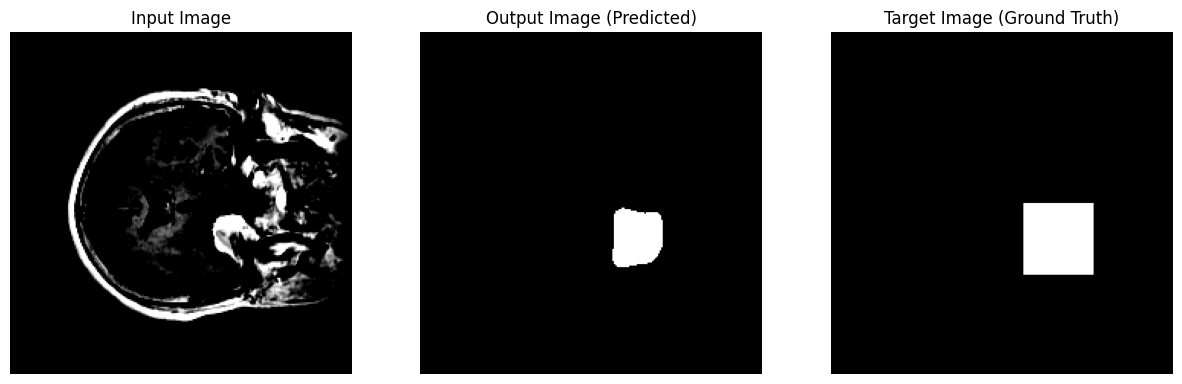

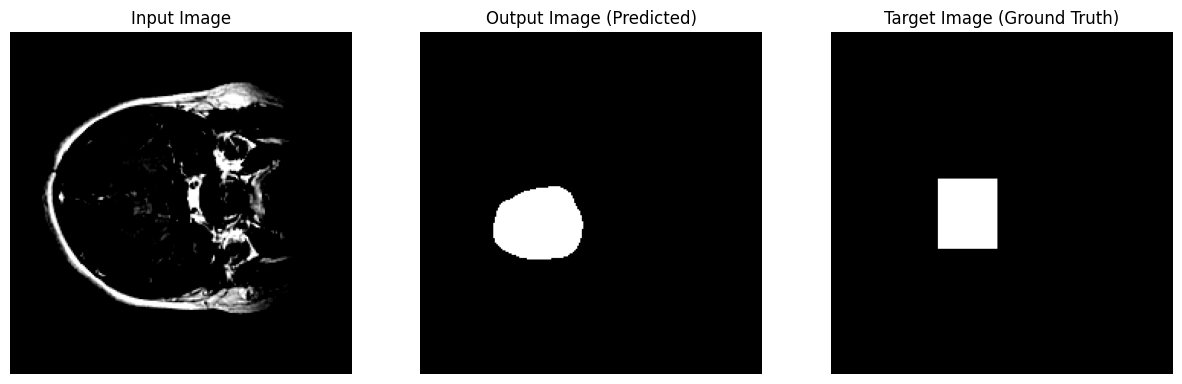

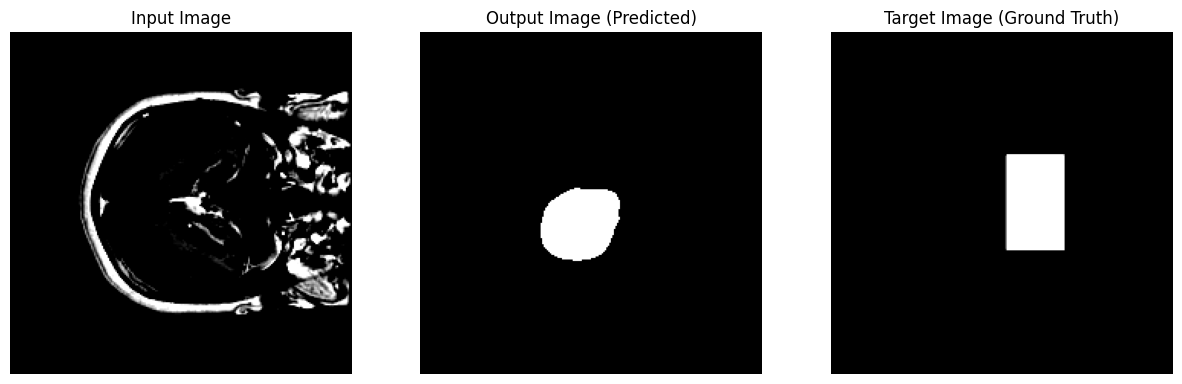

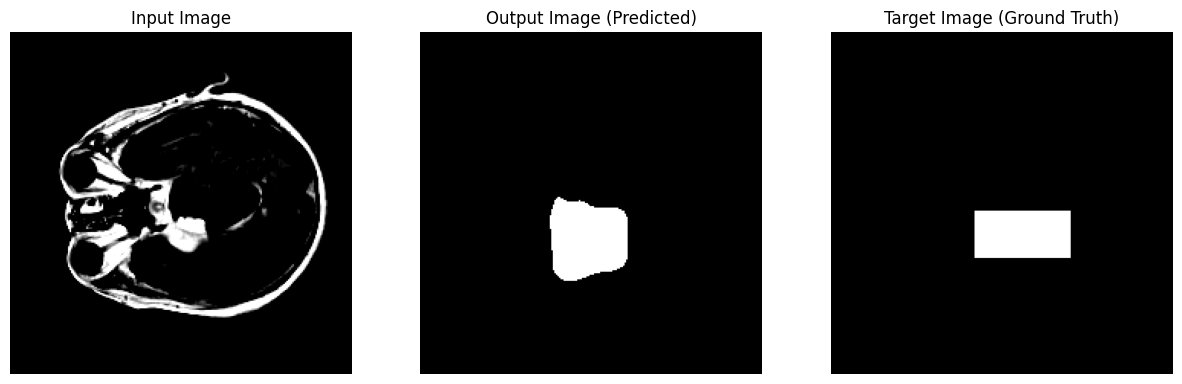

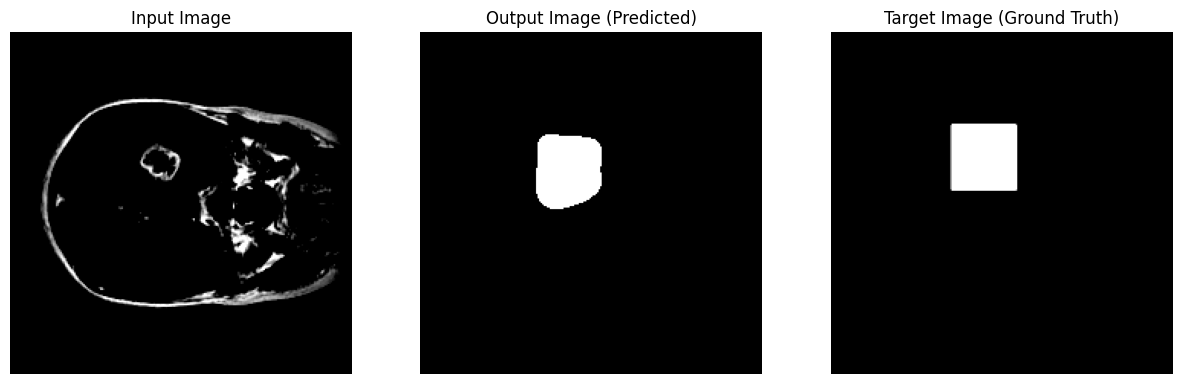

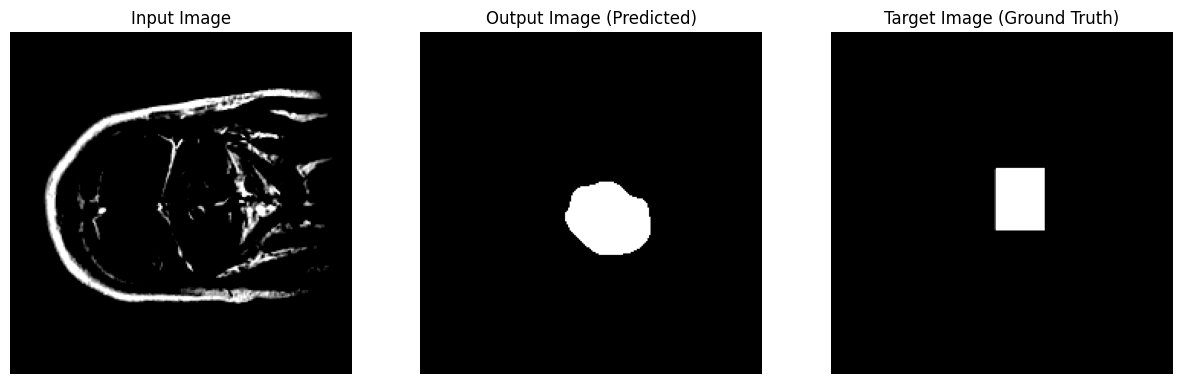

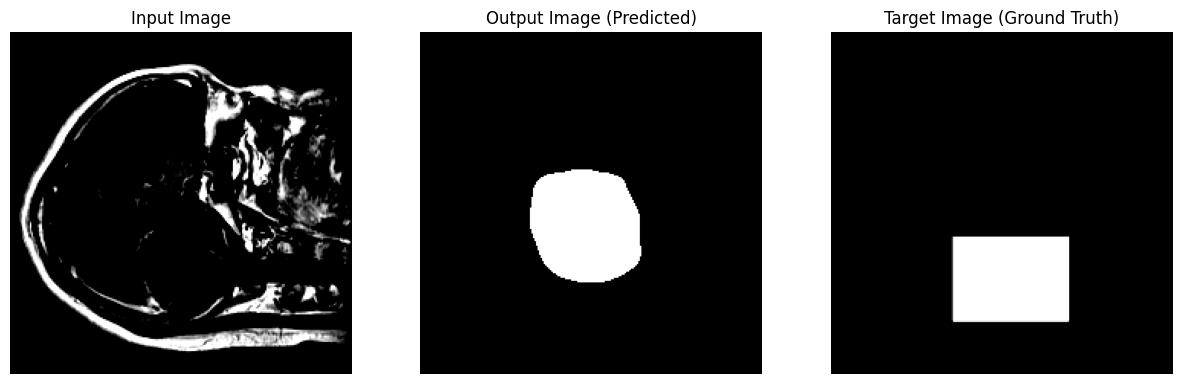

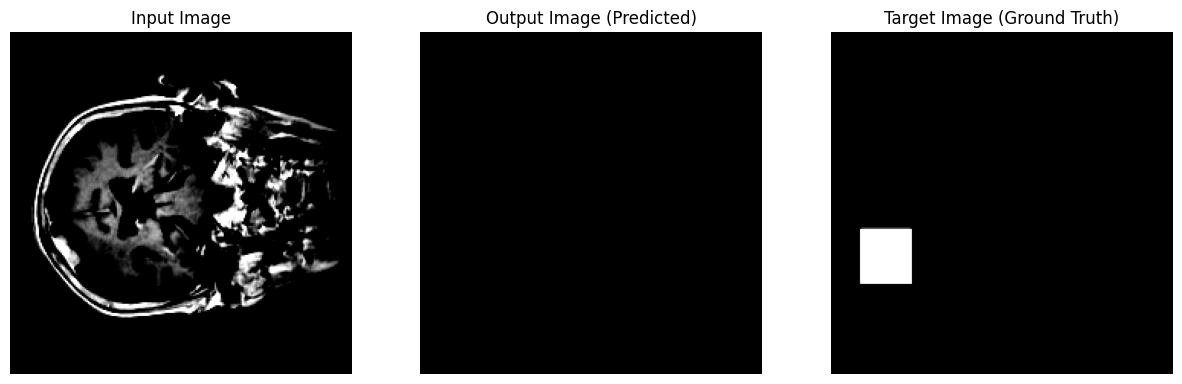

In [14]:
def visualize_images(input_img, output_img, target_img):
    # Move tensors to CPU if they are on CUDA devices
    input_img = input_img.cpu()
    output_img = output_img.cpu()
    target_img = target_img.cpu()

    # Create a subplot to display images
    fig, axes = plt.subplots(1, 3, figsize=(15, 5))

    # Display input image
    axes[0].imshow(input_img.squeeze().numpy(), cmap='gray')
    axes[0].set_title('Input Image')
    axes[0].axis('off')

    # Display output image (predicted binary mask)
    axes[1].imshow(output_img.squeeze().numpy(), cmap='gray')
    axes[1].set_title('Output Image (Predicted)')
    axes[1].axis('off')

    # Display target image (ground truth binary mask)
    axes[2].imshow(target_img.squeeze().numpy(), cmap='gray')
    axes[2].set_title('Target Image (Ground Truth)')
    axes[2].axis('off')

    plt.show()
    fig.savefig("output.png")

# Inference and visualization
with torch.no_grad():  # Use no_grad() for inference
    for batch_idx, (X_batch, y_batch) in enumerate(valid_loader):
        X_batch = X_batch.to(DEVICE, dtype=torch.float32)
        y_batch = y_batch.to(DEVICE, dtype=torch.float32)

        y_pred_logits = unet2(X_batch)
        
        # Apply threshold to get binary predictions
        y_pred_binary = (y_pred_logits > 0.5).float()

        # Visualize the input, predicted output, and target images for the first sample in the batch
        visualize_images(X_batch[0], y_pred_binary[0], y_batch[0])


/tmp/ipykernel_219/3678584634.py:22: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model.load_state_dict(torch.load('best_model.pth'))


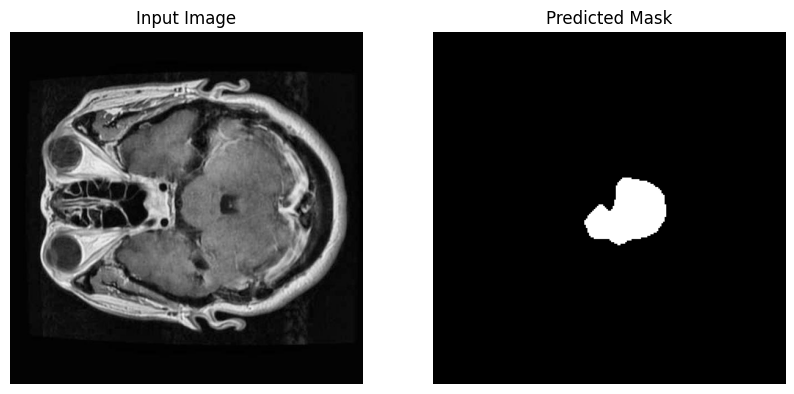

In [15]:
import torch
import segmentation_models_pytorch as smp
import cv2
import numpy as np
import matplotlib.pyplot as plt

# Model configuration
ENCODER = 'resnet34'
ENCODER_WEIGHTS = 'imagenet'
DEVICE = 'cuda' if torch.cuda.is_available() else 'cpu'

# Define the Unet model
model = smp.Unet(
    encoder_name=ENCODER,
    encoder_weights=ENCODER_WEIGHTS,
    in_channels=1,  # Input channels for grayscale images
    classes=1,      # Output classes
    activation=None
)

# Load the saved model weights
model.load_state_dict(torch.load('best_model.pth'))
model.to(DEVICE)
model.eval()  # Set the model to evaluation mode

# Function to preprocess the image
def preprocess_image(image_path):
    # Read the image using OpenCV
    image = cv2.imread(image_path, cv2.IMREAD_GRAYSCALE)  # Load as grayscale
    image = cv2.resize(image, (224, 224))  # Resize to match the model input size
    image = image.astype(np.float32) / 255.0  # Normalize to [0, 1]
    image = np.expand_dims(image, axis=0)  # Add batch dimension
    image = np.expand_dims(image, axis=0)  # Add channel dimension (1 channel for grayscale)
    return torch.tensor(image).to(DEVICE)

# Function to make a prediction
def predict(image_path):
    input_image = preprocess_image(image_path)
    
    with torch.no_grad():  # Disable gradient calculation
        output_logits = model(input_image)
        
    # Apply sigmoid to get probabilities and threshold
    output_prob = torch.sigmoid(output_logits)
    prediction = (output_prob > 0.5).float()  # Convert to binary mask
    
    return prediction.squeeze().cpu().numpy()  # Move back to CPU and remove unnecessary dimensions

# Path to the image you want to predict
image_path = '/kaggle/input/brain-tumor-image-dataset-semantic-segmentation/valid/1006_jpg.rf.9e260b2c3d87e68b706022359921b4e0.jpg'  # Change to the path of your image

# Make a prediction
predicted_mask = predict(image_path)

# Visualize the input image and predicted mask
plt.figure(figsize=(10, 5))
plt.subplot(1, 2, 1)
plt.imshow(cv2.imread(image_path, cv2.IMREAD_GRAYSCALE), cmap='gray')
plt.title('Input Image')
plt.axis('off')

plt.subplot(1, 2, 2)
plt.imshow(predicted_mask, cmap='gray')
plt.title('Predicted Mask')
plt.axis('off')

plt.show()


# Unet3

Epoch 10/10, Train Loss: 0.4140, Train Jaccard: 0.5515, Train Accuracy: 0.9777
Validation Loss: 0.4815, Validation Jaccard: 0.4961, Validation Accuracy: 0.9735


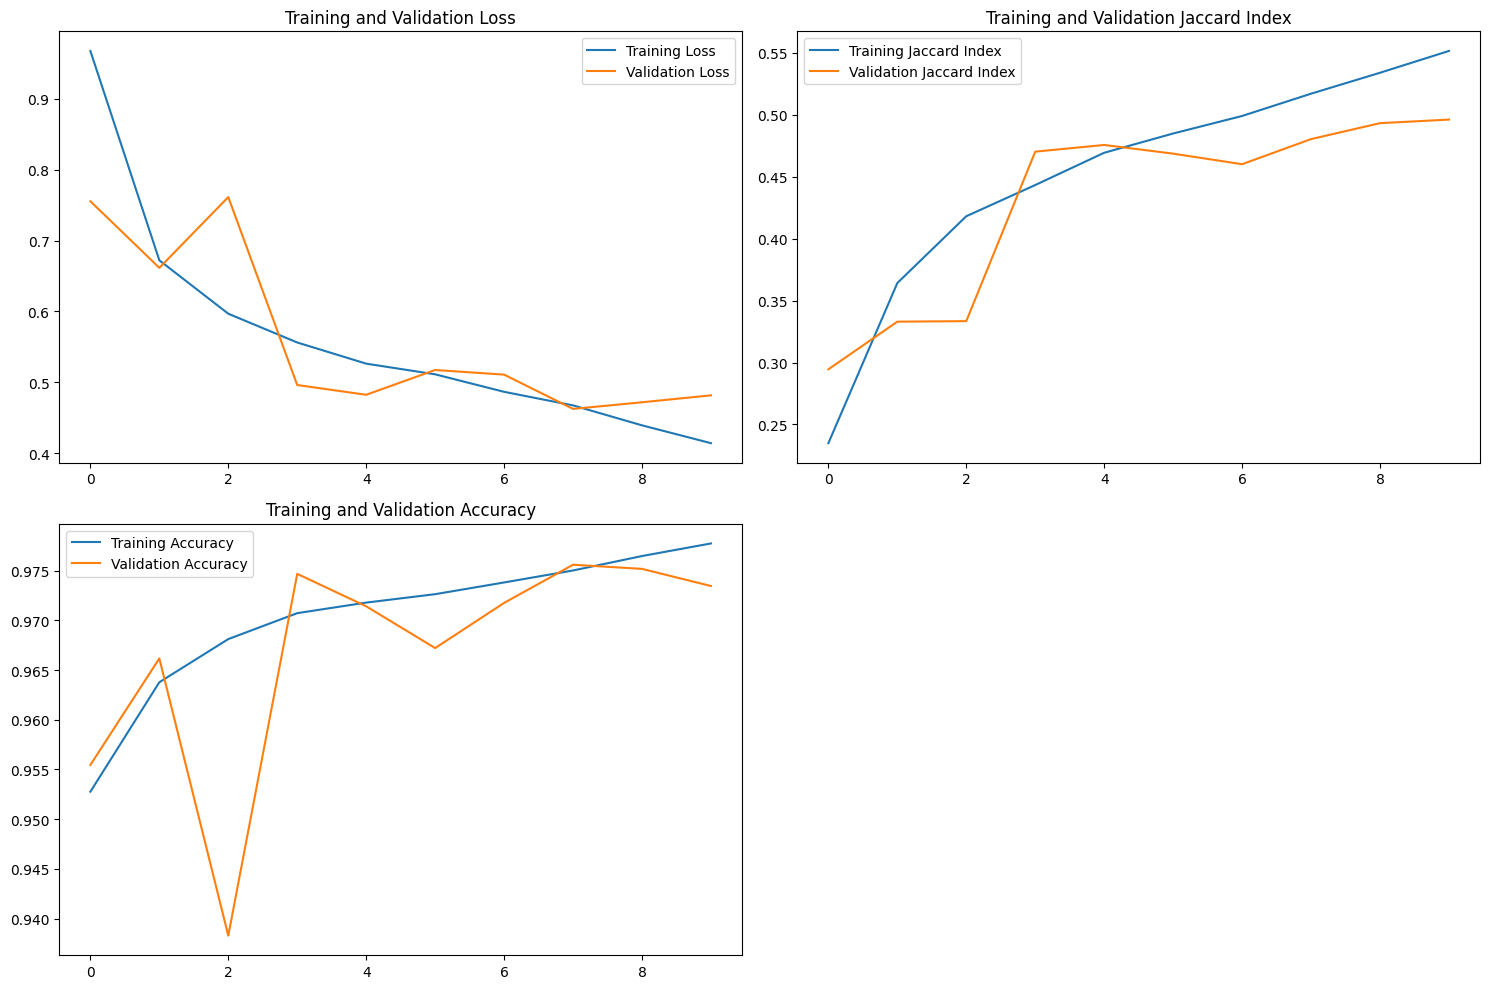

In [17]:
import segmentation_models_pytorch as smp
import torch
import torch.nn as nn
import torch.optim as optim
import torchsummary
from torchvision import transforms
from tqdm import tqdm
from IPython.display import clear_output
import matplotlib.pyplot as plt
import albumentations as A
from albumentations.pytorch import ToTensorV2

# Define Dice Loss Function
class DiceLoss(nn.Module):
    def __init__(self):
        super(DiceLoss, self).__init__()

    def forward(self, y_pred, y_true):
        smooth = 1e-6
        y_pred = torch.sigmoid(y_pred).view(-1)
        y_true = y_true.view(-1)
        intersection = (y_pred * y_true).sum()
        return 1 - (2. * intersection + smooth) / (y_pred.sum() + y_true.sum() + smooth)

# Define Combined Loss Function
class CombinedLoss(nn.Module):
    def __init__(self):
        super(CombinedLoss, self).__init__()
        self.dice_loss = DiceLoss()
        self.bce_loss = nn.BCEWithLogitsLoss()

    def forward(self, y_pred, y_true):
        dice_loss = self.dice_loss(y_pred, y_true)
        bce_loss = self.bce_loss(y_pred, y_true)
        return dice_loss + bce_loss

# Jaccard Index Function
def jaccard_index(predictions, targets, smooth=1e-10):
    predictions = (predictions > 0.5).float()
    intersection = (predictions * targets).sum(dim=(2, 3))
    union = predictions.sum(dim=(2, 3)) + targets.sum(dim=(2, 3)) - intersection
    return (intersection + smooth) / (union + smooth)

# Accuracy Calculation
def calculate_accuracy(predictions, targets):
    predictions = (predictions > 0.5).float()
    correct = (predictions == targets).float().sum()  # Count correct predictions
    accuracy = correct / (targets.numel())  # Divide by total number of pixels
    return accuracy.item()

# Training Function
def train_model(model, optimizer, loss_function, data_loader, device):
    total_loss = 0.0
    total_jaccard = 0.0
    total_accuracy = 0.0
    model.train()

    for inputs, targets in tqdm(data_loader):
        inputs = inputs.to(device, dtype=torch.float32)
        targets = targets.to(device, dtype=torch.float32)

        optimizer.zero_grad()
        predictions = model(inputs)
        loss = loss_function(predictions, targets)
        loss.backward()
        optimizer.step()

        total_loss += loss.item()
        batch_jaccard = jaccard_index(predictions, targets).mean().item()
        total_jaccard += batch_jaccard
        batch_accuracy = calculate_accuracy(predictions, targets)
        total_accuracy += batch_accuracy

    avg_loss = total_loss / len(data_loader)
    avg_jaccard = total_jaccard / len(data_loader)
    avg_accuracy = total_accuracy / len(data_loader)
    return avg_loss, avg_jaccard, avg_accuracy

# Validation Function
def validate_model(model, data_loader, loss_function, device):
    total_loss = 0.0
    total_jaccard = 0.0
    total_accuracy = 0.0
    model.eval()

    with torch.no_grad():
        for inputs, targets in data_loader:
            inputs = inputs.to(device, dtype=torch.float32)
            targets = targets.to(device, dtype=torch.float32)

            predictions = model(inputs)
            loss = loss_function(predictions, targets)
            total_loss += loss.item()

            batch_jaccard = jaccard_index(predictions, targets).mean().item()
            total_jaccard += batch_jaccard
            batch_accuracy = calculate_accuracy(predictions, targets)
            total_accuracy += batch_accuracy

    avg_loss = total_loss / len(data_loader)
    avg_jaccard = total_jaccard / len(data_loader)
    avg_accuracy = total_accuracy / len(data_loader)
    return avg_loss, avg_jaccard, avg_accuracy

# Model configuration
ENCODER = 'resnet50'  # Use ResNet34 as the encoder
ENCODER_WEIGHTS = 'imagenet'
DEVICE = 'cuda' if torch.cuda.is_available() else 'cpu'

# Define the Unet model
unet3 = smp.Unet(
    encoder_name=ENCODER,
    encoder_weights=ENCODER_WEIGHTS,
    in_channels=1,  # Input channels for grayscale images
    classes=1,      # Output classes
    activation=None
)

# Move the model to the specified device
unet3.to(DEVICE)

# Print the summary of unet3 model
print(torchsummary.summary(unet3, (1, 224, 224)))

# Define Data Transformations with Albumentations
def get_transforms():
    return A.Compose([
        A.Resize(224, 224),
        A.HorizontalFlip(),
        A.VerticalFlip(),
        A.RandomRotate90(),
        A.RandomBrightnessContrast(),
        A.Normalize(mean=(0.485,), std=(0.229,)),
        ToTensorV2()
    ])

# Define Optimizer and Scheduler
LEARNING_RATE = 0.001
optimizer = optim.Adam(unet3.parameters(), lr=LEARNING_RATE)
scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, 'min', patience=2, factor=0.5)
loss_fn = CombinedLoss()

# Variables for training
NUM_EPOCHS = 10
best_validation_loss = float('inf')
num_no_improve = 0
train_losses = []
val_losses = []
train_jaccards = []
val_jaccards = []
train_accuracies = []
val_accuracies = []

# Training Loop
for epoch in range(NUM_EPOCHS):
    train_loss, train_jaccard, train_accuracy = train_model(unet3, optimizer, loss_fn, train_loader, DEVICE)
    val_loss, val_jaccard, val_accuracy = validate_model(unet3, valid_loader, loss_fn, DEVICE)

    train_losses.append(train_loss)
    val_losses.append(val_loss)
    train_jaccards.append(train_jaccard)
    val_jaccards.append(val_jaccard)
    train_accuracies.append(train_accuracy)
    val_accuracies.append(val_accuracy)

    clear_output(wait=True)
    print(f'Epoch {epoch + 1}/{NUM_EPOCHS}, Train Loss: {train_loss:.4f}, Train Jaccard: {train_jaccard:.4f}, Train Accuracy: {train_accuracy:.4f}')
    print(f'Validation Loss: {val_loss:.4f}, Validation Jaccard: {val_jaccard:.4f}, Validation Accuracy: {val_accuracy:.4f}')

    # Save the best model
    if val_loss < best_validation_loss:
        best_validation_loss = val_loss
        torch.save(unet3.state_dict(), 'best_model_unet3.pth')  # Save the best model weights
        print("Saving the best model...")

    # Learning rate scheduler
    scheduler.step(val_loss)

    # Early stopping logic
    if num_no_improve >= 5:
        print("Early stopping triggered.")
        break

# Plotting the training and validation losses, Jaccard indices, and accuracies
plt.figure(figsize=(15, 10))

# Loss Plot
plt.subplot(2, 2, 1)
plt.plot(train_losses, label='Training Loss')
plt.plot(val_losses, label='Validation Loss')
plt.title('Training and Validation Loss')
plt.legend()

# Jaccard Index Plot
plt.subplot(2, 2, 2)
plt.plot(train_jaccards, label='Training Jaccard Index')
plt.plot(val_jaccards, label='Validation Jaccard Index')
plt.title('Training and Validation Jaccard Index')
plt.legend()

# Accuracy Plot
plt.subplot(2, 2, 3)
plt.plot(train_accuracies, label='Training Accuracy')
plt.plot(val_accuracies, label='Validation Accuracy')
plt.title('Training and Validation Accuracy')
plt.legend()

plt.tight_layout()
plt.show()


/tmp/ipykernel_219/3192027677.py:22: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model.load_state_dict(torch.load('best_model_unet3.pth'))


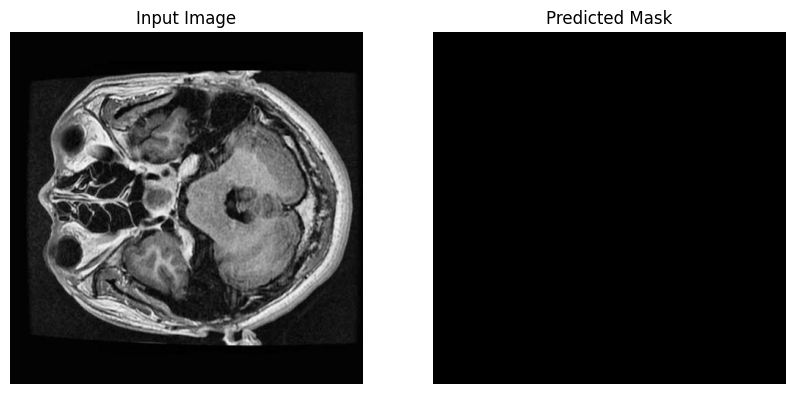

In [21]:
import torch
import segmentation_models_pytorch as smp
import cv2
import numpy as np
import matplotlib.pyplot as plt

# Model configuration
ENCODER = 'resnet50'  # Use the same encoder as in training
ENCODER_WEIGHTS = 'imagenet'
DEVICE = 'cuda' if torch.cuda.is_available() else 'cpu'

# Define the Unet model
model = smp.Unet(
    encoder_name=ENCODER,
    encoder_weights=ENCODER_WEIGHTS,
    in_channels=1,  # Input channels for grayscale images
    classes=1,      # Output classes
    activation=None
)

# Load the saved model weights
model.load_state_dict(torch.load('best_model_unet3.pth'))
model.to(DEVICE)
model.eval()  # Set the model to evaluation mode

# Function to preprocess the image
def preprocess_image(image_path):
    # Read the image using OpenCV
    image = cv2.imread(image_path, cv2.IMREAD_GRAYSCALE)  # Load as grayscale
    image = cv2.resize(image, (224, 224))  # Resize to match the model input size
    image = image.astype(np.float32) / 255.0  # Normalize to [0, 1]
    image = np.expand_dims(image, axis=0)  # Add batch dimension
    image = np.expand_dims(image, axis=0)  # Add channel dimension (1 channel for grayscale)
    return torch.tensor(image).to(DEVICE)

# Function to make a prediction
def predict(image_path):
    input_image = preprocess_image(image_path)
    
    with torch.no_grad():  # Disable gradient calculation
        output_logits = model(input_image)
        
    # Apply sigmoid to get probabilities and threshold
    output_prob = torch.sigmoid(output_logits)
    prediction = (output_prob > 0.5).float()  # Convert to binary mask
    
    return prediction.squeeze().cpu().numpy()  # Move back to CPU and remove unnecessary dimensions

# Path to the image you want to predict
image_path = '/kaggle/input/brain-tumor-image-dataset-semantic-segmentation/test/1030_jpg.rf.4bfc0ebc72d835cb9668219cd911c249.jpg'  # Change to the path of your image

# Make a prediction
predicted_mask = predict(image_path)

# Visualize the input image and predicted mask
plt.figure(figsize=(10, 5))
plt.subplot(1, 2, 1)
plt.imshow(cv2.imread(image_path, cv2.IMREAD_GRAYSCALE), cmap='gray')
plt.title('Input Image')
plt.axis('off')

plt.subplot(1, 2, 2)
plt.imshow(predicted_mask, cmap='gray')
plt.title('Predicted Mask')
plt.axis('off')

plt.show()


In [22]:
!python --version


# Check the version of TensorFlow
import tensorflow as tf
print(f"TensorFlow version: {tf.__version__}")

# Check the version of Keras (if separate)
import keras
print(f"Keras version: {keras.__version__}")

# Check the version of NumPy
import numpy as np
print(f"NumPy version: {np.__version__}")

# Check the version of pandas
import pandas as pd
print(f"Pandas version: {pd.__version__}")

# Check the version of sklearn
import sklearn
print(f"scikit-learn version: {sklearn.__version__}")

import torch
print(f"torch version: {torch.__version__}")

import segmentation_models_pytorch
print(f"segmentation_models_pytorch version: {segmentation_models_pytorch.__version__}")

import torchvision
print(f"torchvision version: {torchvision.__version__}")

import cv2
print(f"cv2 version: {cv2.__version__}")

Python 3.10.14
TensorFlow version: 2.16.1
Keras version: 3.3.3
NumPy version: 1.26.4
Pandas version: 2.2.3
scikit-learn version: 1.2.2
torch version: 2.4.0
segmentation_models_pytorch version: 0.3.4
torchvision version: 0.19.0
cv2 version: 4.10.0
